# Reversal detection

Here, I detect emotional reversals in the secondary arc of each script. It runs entirely locally on the pre-computed arcs in `thesis-outputs/arcs/arcs_all.json`. No model inference needed. I define "reversal" as a local peak or trough in the Savitzky-Golay smoothed secondary arc. For each script I record: the total number of reversals, the normalized story position of each reversal (0–1), whether it is a peak (positive > negative turn) or a trough (negative > positive turn), and the sentiment value at that point. This lets me compare not just how many reversals a film contains, but where in the story they tend to cluster.

## 1. Load arcs

In [1]:
%pip install -q scipy numpy matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import numpy as np
from pathlib import Path
from scipy.signal import find_peaks

LOCAL_ROOT = Path('/Users/derinsavasan/Desktop/parsons-spring/thesis')
ARCS_ALL   = LOCAL_ROOT / 'docs/thesis-outputs/arcs_all.json'

all_arcs = json.loads(ARCS_ALL.read_text())
print(f'Loaded {len(all_arcs)} arcs')

Loaded 1627 arcs


## 2. Detect reversals

I use `scipy.signal.find_peaks` on the smoothed secondary arc to find peaks, and on its inverse to find troughs. The `prominence` parameter controls how significant a swing needs to be to count as a reversal. I ignore small ripples and only record meaningful directional changes. I set the prominance to 0.5 (on the signed sentiment scale of −1 to +1). This can be tuned, of course.

In [3]:
PROMINENCE = 0.5  # minimum prominence to count as a reversal

results = []

for arc in all_arcs:
    secondary = arc['secondary_arc']
    if not secondary:
        continue

    positions = np.array([w['position']       for w in secondary])
    values    = np.array([w['smoothed_score'] for w in secondary])

    # Peaks — sentiment goes up then down
    peak_idxs,   _ = find_peaks( values, prominence=PROMINENCE)
    # Troughs — sentiment goes down then up
    trough_idxs, _ = find_peaks(-values, prominence=PROMINENCE)

    reversals = [
        {'position': float(positions[i]), 'value': float(values[i]), 'type': 'peak'}
        for i in peak_idxs
    ] + [
        {'position': float(positions[i]), 'value': float(values[i]), 'type': 'trough'}
        for i in trough_idxs
    ]
    reversals.sort(key=lambda r: r['position'])

    results.append({
        'slug':        arc['slug'],
        'title':       arc['title'],
        'imdb_id':     arc['imdb_id'],
        'year':        arc['year'],
        'n_reversals': len(reversals),
        'reversals':   reversals,
    })

print(f'Processed {len(results)} scripts')
print(f'Avg reversals per film : {np.mean([r["n_reversals"] for r in results]):.1f}')
print(f'Max reversals          : {max(r["n_reversals"] for r in results)}')
print(f'Min reversals          : {min(r["n_reversals"] for r in results)}')

Processed 1627 scripts
Avg reversals per film : 10.8
Max reversals          : 31
Min reversals          : 0


## 3. Save

In [4]:
out = LOCAL_ROOT / 'docs/thesis-outputs/reversals.json'
out.write_text(json.dumps(results, indent=2))
print(f'Saved -> {out}')

Saved -> /Users/derinsavasan/Desktop/parsons-spring/thesis/docs/thesis-outputs/reversals.json


## 4. Spot-check one script

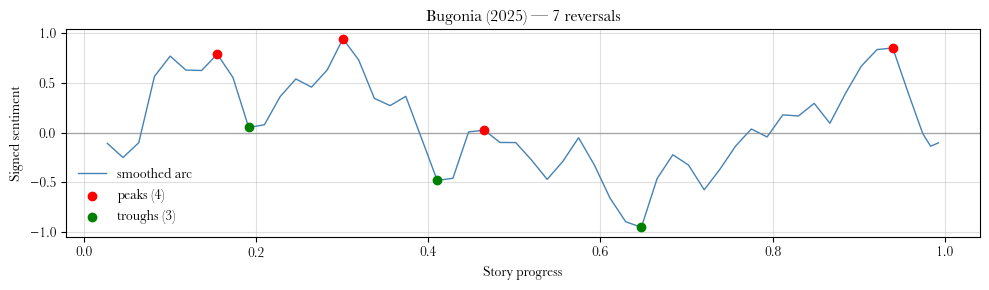

In [13]:
import random, matplotlib.pyplot as plt

# Pick a random script
arc    = random.choice(all_arcs)
result = next(r for r in results if r['slug'] == arc['slug'])

positions = [w['position']       for w in arc['secondary_arc']]
values    = [w['smoothed_score'] for w in arc['secondary_arc']]

peaks   = [r for r in result['reversals'] if r['type'] == 'peak']
troughs = [r for r in result['reversals'] if r['type'] == 'trough']

plt.figure(figsize=(10, 3))
plt.plot(positions, values, linewidth=1, color='steelblue', label='smoothed arc')
plt.scatter([r['position'] for r in peaks],   [r['value'] for r in peaks],
            color='red',   zorder=5, label=f'peaks ({len(peaks)})')
plt.scatter([r['position'] for r in troughs], [r['value'] for r in troughs],
            color='green', zorder=5, label=f'troughs ({len(troughs)})')
plt.axhline(0, color='gray', lw=1, alpha=0.6)
plt.title(f"{result['title']} ({result['year']}) — {result['n_reversals']} reversals")
plt.xlabel('Story progress')
plt.ylabel('Signed sentiment')
plt.legend(frameon=False)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Corpus-level analysis

Join reversal counts with genre and decade metadata from the clustered CSV, then break down reversal statistics by decade and by genre.

In [6]:
import csv

# Load genre / decade metadata from the clustered CSV
meta = {}
with open(LOCAL_ROOT / 'docs/thesis-outputs/emotional_arcs_clustered.csv') as f:
    for row in csv.DictReader(f):
        meta[row['film_id']] = {
            'primary_genre': row['primary_genre'],
            'decade':        row['decade'],
        }

# Attach metadata to reversal results
for r in results:
    m = meta.get(r['imdb_id'], {})
    r['primary_genre'] = m.get('primary_genre', 'Unknown')
    r['decade']        = m.get('decade', 'Unknown')

matched = sum(1 for r in results if r['primary_genre'] != 'Unknown')
print(f'Matched {matched}/{len(results)} scripts to genre/decade metadata')

Matched 1625/1627 scripts to genre/decade metadata


### 5a. Reversals by decade

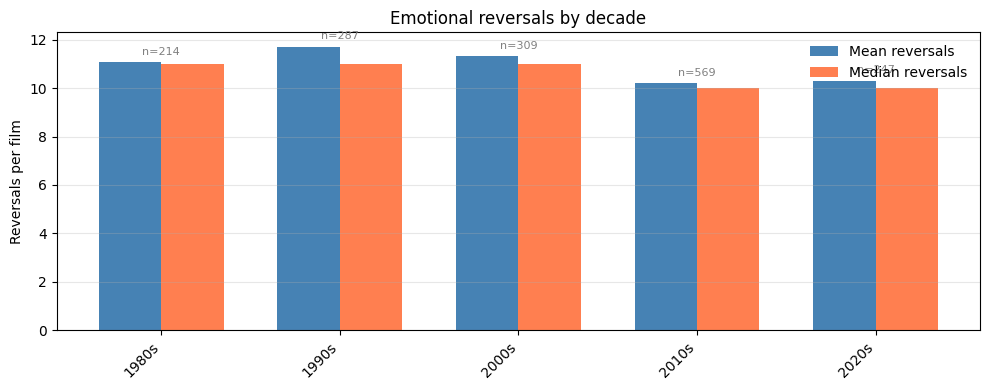

Decade         n   Mean  Median    Std  Min  Max
------------------------------------------------
1980s        214   11.1    11.0    3.5    1   28
1990s        287   11.7    11.0    4.1    4   31
2000s        309   11.3    11.0    3.7    2   29
2010s        569   10.2    10.0    3.5    0   26
2020s        247   10.3    10.0    3.5    3   23


In [7]:
from collections import defaultdict

# Group reversal counts by decade
by_decade = defaultdict(list)
for r in results:
    if r['decade'] != 'Unknown':
        by_decade[r['decade']].append(r['n_reversals'])

decades_sorted = sorted(by_decade.keys())
means  = [np.mean(by_decade[d]) for d in decades_sorted]
medians = [np.median(by_decade[d]) for d in decades_sorted]
counts = [len(by_decade[d]) for d in decades_sorted]

fig, ax1 = plt.subplots(figsize=(10, 4))
x = np.arange(len(decades_sorted))
width = 0.35

bars = ax1.bar(x - width/2, means, width, label='Mean reversals', color='steelblue')
ax1.bar(x + width/2, medians, width, label='Median reversals', color='coral')
ax1.set_xticks(x)
ax1.set_xticklabels(decades_sorted, rotation=45, ha='right')
ax1.set_ylabel('Reversals per film')
ax1.set_title('Emotional reversals by decade')
ax1.legend(frameon=False)

# Annotate film counts
for i, c in enumerate(counts):
    ax1.text(i, max(means[i], medians[i]) + 0.3, f'n={c}', ha='center', fontsize=8, color='gray')

ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(LOCAL_ROOT / 'docs/thesis-outputs/reversals_by_decade.png', dpi=200, bbox_inches='tight')
plt.show()

# Print table
print(f'{"Decade":<10} {"n":>5} {"Mean":>6} {"Median":>7} {"Std":>6} {"Min":>4} {"Max":>4}')
print('-' * 48)
for d in decades_sorted:
    vals = by_decade[d]
    print(f'{d:<10} {len(vals):>5} {np.mean(vals):>6.1f} {np.median(vals):>7.1f} {np.std(vals):>6.1f} {min(vals):>4} {max(vals):>4}')

### 5b. Reversals by genre

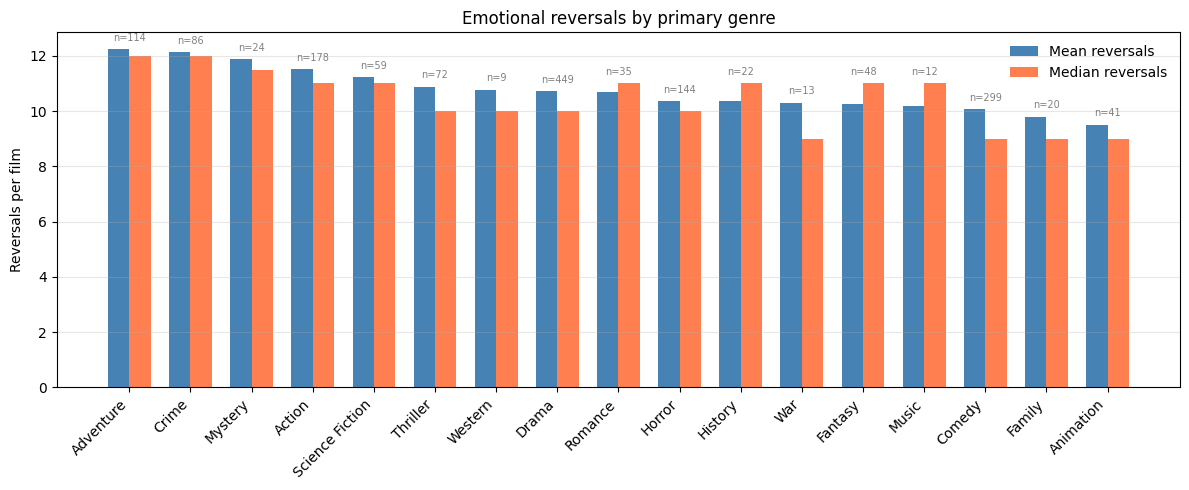

Genre                n   Mean  Median    Std  Min  Max
----------------------------------------------------
Adventure          114   12.2    12.0    3.9    2   25
Crime               86   12.1    12.0    4.4    3   30
Mystery             24   11.9    11.5    2.6    8   19
Action             178   11.5    11.0    3.3    4   22
Science Fiction     59   11.2    11.0    3.6    5   23
Thriller            72   10.9    10.0    3.5    4   28
Western              9   10.8    10.0    3.2    7   17
Drama              449   10.7    10.0    4.0    0   31
Romance             35   10.7    11.0    3.6    5   23
Horror             144   10.4    10.0    3.5    3   29
History             22   10.4    11.0    3.8    3   21
War                 13   10.3     9.0    4.4    5   23
Fantasy             48   10.3    11.0    3.5    3   20
Music               12   10.2    11.0    3.4    1   15
Comedy             299   10.1     9.0    3.1    2   20
Family              20    9.8     9.0    3.2    5   18
Animation   

In [8]:
# Group reversal counts by primary genre
by_genre = defaultdict(list)
for r in results:
    if r['primary_genre'] != 'Unknown':
        by_genre[r['primary_genre']].append(r['n_reversals'])

# Sort genres by mean reversal count (descending)
genres_sorted = sorted(by_genre.keys(), key=lambda g: np.mean(by_genre[g]), reverse=True)
genre_means   = [np.mean(by_genre[g]) for g in genres_sorted]
genre_medians = [np.median(by_genre[g]) for g in genres_sorted]
genre_counts  = [len(by_genre[g]) for g in genres_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(genres_sorted))
width = 0.35

ax.bar(x - width/2, genre_means, width, label='Mean reversals', color='steelblue')
ax.bar(x + width/2, genre_medians, width, label='Median reversals', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(genres_sorted, rotation=45, ha='right')
ax.set_ylabel('Reversals per film')
ax.set_title('Emotional reversals by primary genre')
ax.legend(frameon=False)

for i, c in enumerate(genre_counts):
    ax.text(i, max(genre_means[i], genre_medians[i]) + 0.3, f'n={c}', ha='center', fontsize=7, color='gray')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(LOCAL_ROOT / 'docs/thesis-outputs/reversals_by_genre.png', dpi=200, bbox_inches='tight')
plt.show()

# Print table
print(f'{"Genre":<16} {"n":>5} {"Mean":>6} {"Median":>7} {"Std":>6} {"Min":>4} {"Max":>4}')
print('-' * 52)
for g in genres_sorted:
    vals = by_genre[g]
    print(f'{g:<16} {len(vals):>5} {np.mean(vals):>6.1f} {np.median(vals):>7.1f} {np.std(vals):>6.1f} {min(vals):>4} {max(vals):>4}')

### 5c. Where in the story do reversals cluster?

KDE density curves of reversal positions (0 = start, 1 = end) across the corpus, faceted by decade and genre.

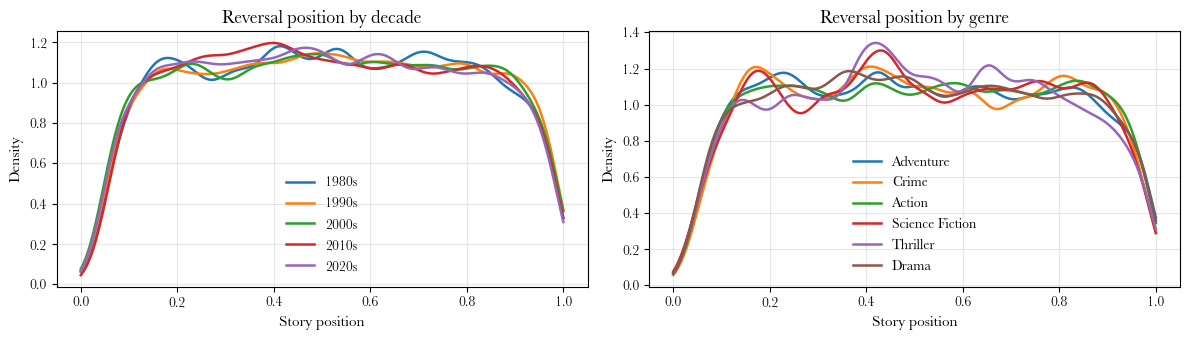

In [9]:
from scipy.stats import gaussian_kde

plt.rcParams['font.family'] = 'Baskerville'

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
xs = np.linspace(0, 1, 200)

# --- By decade ---
ax = axes[0]
top_decades = [d for d in decades_sorted if len(by_decade[d]) >= 30]
for d in top_decades:
    pos = [rev['position'] for r in results if r['decade'] == d for rev in r['reversals']]
    if len(pos) > 10:
        kde = gaussian_kde(pos, bw_method=0.12)
        ax.plot(xs, kde(xs), label=d, linewidth=1.8)
ax.set_xlabel('Story position', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Reversal position by decade', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, frameon=False)
ax.tick_params(labelsize=10)
ax.grid(alpha=0.3)

# --- By genre ---
ax = axes[1]
top_genres = [g for g in genres_sorted if len(by_genre[g]) >= 50][:6]
for g in top_genres:
    pos = [rev['position'] for r in results if r['primary_genre'] == g for rev in r['reversals']]
    if len(pos) > 10:
        kde = gaussian_kde(pos, bw_method=0.12)
        ax.plot(xs, kde(xs), label=g, linewidth=1.8)
ax.set_xlabel('Story position', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Reversal position by genre', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, frameon=False)
ax.tick_params(labelsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(LOCAL_ROOT / 'docs/thesis-outputs/reversal_position_density.png', dpi=200, bbox_inches='tight')
plt.show()